In [1]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import gymnasium as gym
from gymnasium import spaces
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from stable_baselines3.common.env_checker import check_env
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG # Ganti PPO ke DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
from sb3_contrib import TRPO
print("INFO: Import Library")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


INFO: Import Library


# Load Dataset

In [2]:
# Function to load mat file
def load_mat_file(file_path):
    path =Path(file_path)
    try:
        mat = scipy.io.loadmat(path)
        if 'meas' not in mat:
            print(f"ERROR: Key 'meas' is not found in {path.name}")
            return None
        
        data_struct = mat["meas"][0,0]
        names = data_struct.dtype.names
        raw_data = {}
        for name in names:
            content = data_struct[name].flatten()
            
            if len(content) > 0 and isinstance(content[0], np.ndarray):
                raw_data[name] = content[0].flatten()
            else:
                raw_data[name] = content
            
        lengths = [len(v) for v in raw_data.values() if isinstance(v, (np.ndarray, list))]
        max_len = max(lengths) if lengths else 1

        final_data = {}
        for name, values in raw_data.items():
            curr_len = len(values) if isinstance(values, (np.ndarray, list)) else 1
            
            if curr_len != max_len:
                single_val = values[0] if curr_len > 0 else np.nan
                if hasattr(single_val, 'decode'):
                    single_val = single_val.decode('utf-8')
                final_data[name] = [single_val] * max_len
            else:
                if isinstance(values, np.ndarray) and values.dtype.kind in ['S', 'V']:
                    final_data[name] = [v.decode('utf-8') if hasattr(v, 'decode') else v for v in values]
                else:
                    final_data[name] = values

        df = pd.DataFrame(final_data)
        return df


    except Exception as e:
        print(f"ERROR: Failed to load {path.name}. {e}")

In [3]:
# Load dataset into df_master
base_path = Path('datasets/1-Open Data')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        
        df_temp['Session_ID'] = file_path 
        # df_temp['SOC_lag_1'] = df_temp['SOC'].shift(1)
        # df_temp = df_temp.dropna(subset=['SOC_lag_1'])
        
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")
        
    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)
df_master = df_master.drop(columns=[
    'TimeStamp', 
    'Time', 
    'Battery_Temp_degC', 
    'Ambient_Temp_degC', 
    'Cycle_Label', 
    'Test_Cell', 
    # 'Session_ID'
    ])
df_master.sample(5)

INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_

,Voltage,Current,Ah,SOC,Power,Wh,Session_ID
6972638,4.161811,0.000000,0.000000,1.000000,0.000000,0.000000,datasets/1-Open Data/m1000/0C/Drive Cycles/10_...
10418442,4.199969,0.125836,0.020931,0.995015,0.528505,-3.235000,datasets/1-Open Data/m448-N/-20C/Drive Cycles/...
20026362,4.156154,0.000000,0.000000,1.000000,0.000000,0.000000,datasets/1-Open Data/m80/-10C/Drive Cycles/9_C...
2768142,4.097723,0.000000,0.000000,1.000000,0.000000,0.000000,datasets/1-Open Data/m1000/-20C/Drive Cycles/1...
6766001,3.923823,0.226498,1.476656,0.656689,0.888738,5.499848,datasets/1-Open Data/m1000/0C/Characterization...


# EDA

Text(0.5, 0.98, 'Histogram All Data')

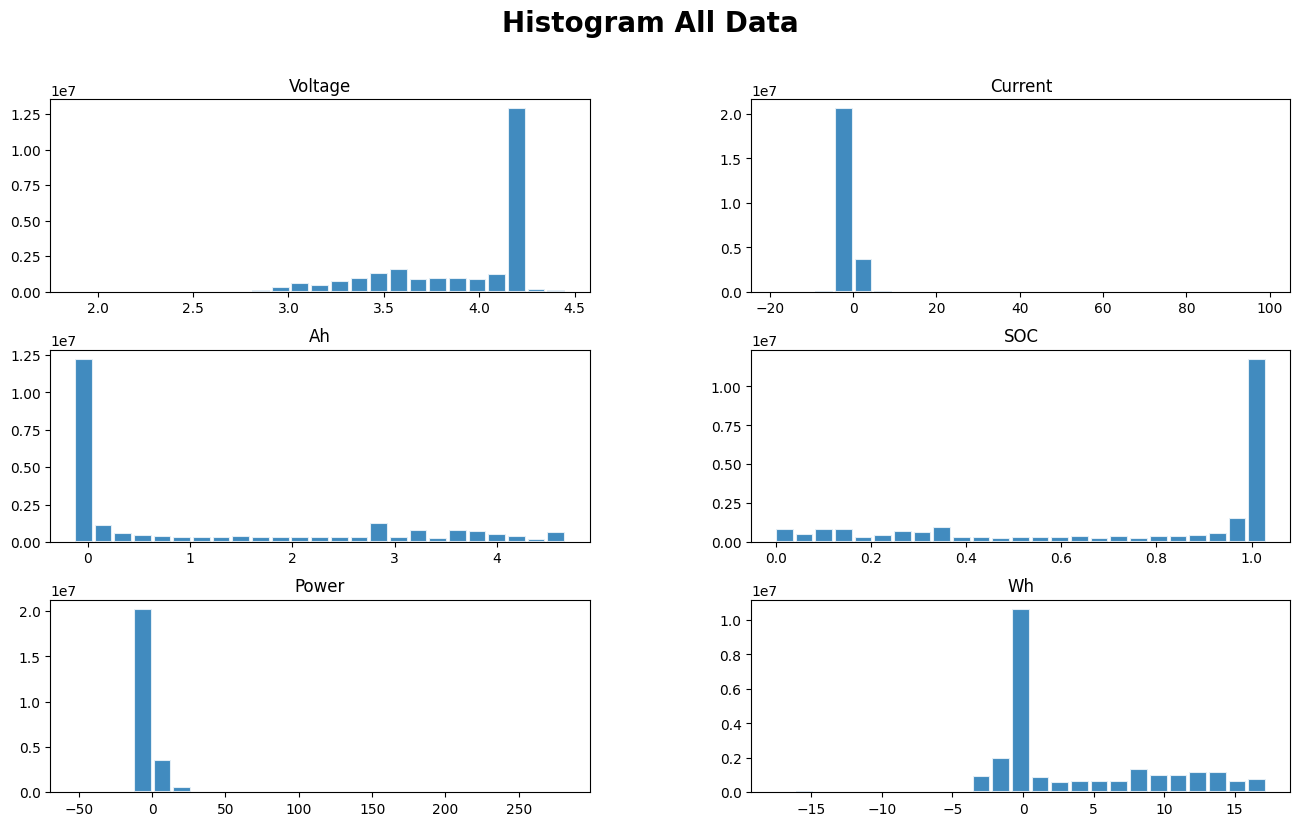

In [4]:
import matplotlib.pyplot as plt

axes = df_master.hist(
    figsize=(16, 9),
    bins=25,
    grid=False,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.85,
    rwidth=0.9,
    sharex=False,
)

# Menambahkan title utama
plt.suptitle(
    'Histogram All Data',
    fontsize=20,
    fontweight='bold'
)

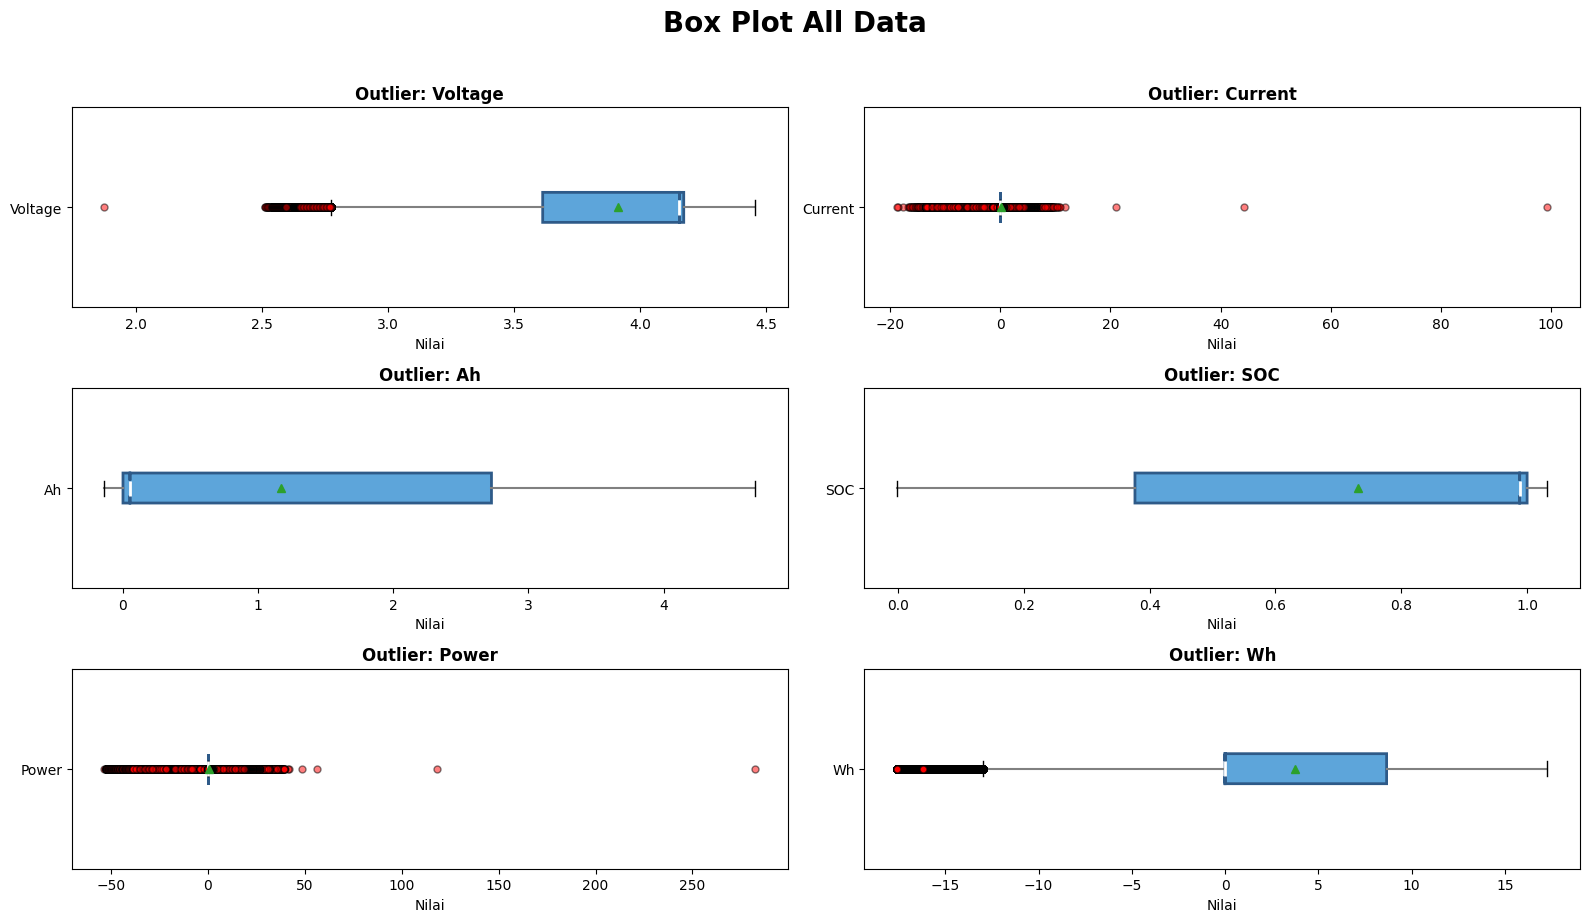

In [5]:
import matplotlib.pyplot as plt

# Ambil hanya kolom numerik
cols = df_master.select_dtypes(include=['number']).columns
n_cols = 2  # Anda bisa ubah jumlah kolom per baris di sini
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    df_master.boxplot(
        column=col,
        ax=axes[i],
        vert=False,
        patch_artist=True,
        notch=True,
        grid=False,
        showmeans=True,
        boxprops={'facecolor': '#5da5da', 'edgecolor': '#2e5a88', 'linewidth': 2},
        whiskerprops={'color': 'gray', 'linewidth': 1.5},
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5, 'alpha': 0.5},
        medianprops={'color': 'white', 'linewidth': 2}
    )
    axes[i].set_title(f'Outlier: {col}', fontweight='bold')
    axes[i].set_xlabel('Nilai')

# Menghapus axes yang tidak terpakai jika jumlah kolom ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Box Plot All Data', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# DF per Weight

In [6]:
# Load dataset into df_master
base_path = Path('datasets/1-Open Data/')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        
        df_temp['Session_ID'] = file_path 
        # df_temp['SOC_lag_1'] = df_temp['SOC'].shift(1)
        # df_temp = df_temp.dropna(subset=['SOC_lag_1'])
        
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")
        
    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)
df_master = df_master.drop(columns=[
    'TimeStamp', 
    'Time', 
    'Battery_Temp_degC', 
    'Ambient_Temp_degC', 
    'Cycle_Label', 
    # 'Test_Cell', 
    # 'Session_ID'
    ])
df_master.sample(5)

INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_

,Voltage,Current,Ah,SOC,Power,Wh,Test_Cell,Session_ID
22428740,3.912130,0.000000,1.18517,0.724219,0.000000,4.30130,m80,datasets/1-Open Data/m80/0C/Characterization T...
23971368,3.717719,0.000000,0.00000,1.000000,0.000000,0.00000,m80,datasets/1-Open Data/m80/25C/Drive Cycles/17_C...
24212101,3.733296,-0.225015,2.36354,0.478247,-0.840046,9.36748,m80,datasets/1-Open Data/m80/25C/Characterization ...
15425192,4.162773,0.000000,0.00000,1.000000,0.000000,0.00000,m448-N,datasets/1-Open Data/m448-N/0C/Drive Cycles/12...
277692,4.200030,0.118924,-0.01210,1.002633,0.499484,-1.52700,m1000,datasets/1-Open Data/m1000/40C/Drive Cycles/13...


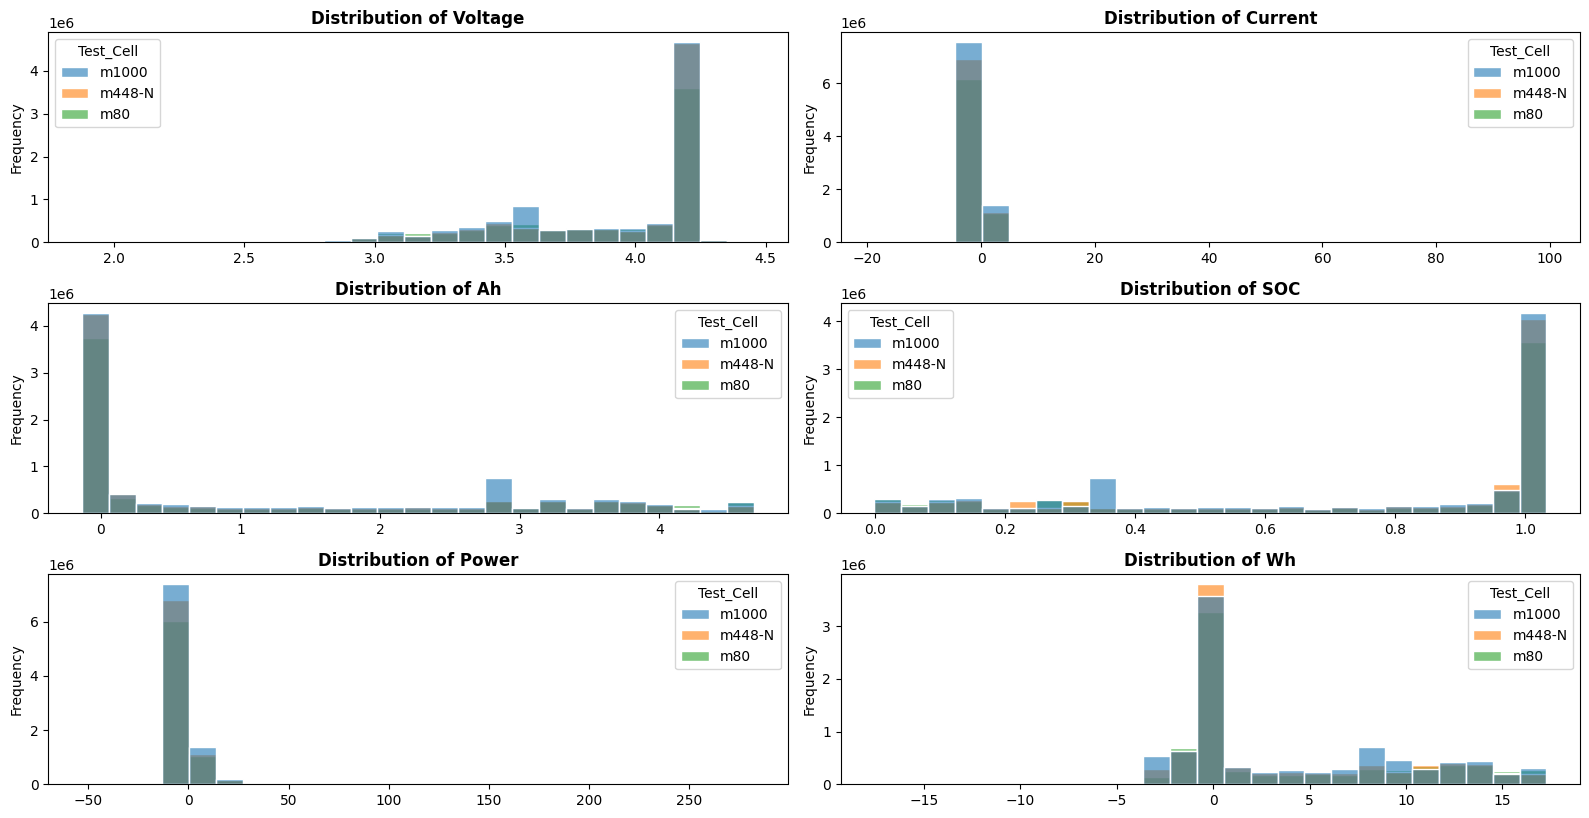

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 9))
axes = axes.flatten()
columns_to_plot = ['Voltage', 'Current', 'Ah', 'SOC', 'Power', 'Wh']

for i, col in enumerate(columns_to_plot):
    sns.histplot(
        data=df_master,
        x=col,
        hue='Test_Cell',
        ax=axes[i],
        bins=25,
        edgecolor='white',
        linewidth=1,
        alpha=0.6,
        element='bars'
    )
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(False)

# plt.suptitle('Comparison Analysis per Test_Cell', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(16, 9))
axes = axes.flatten()
columns_to_plot = ['Voltage', 'Current', 'Ah', 'SOC', 'Power', 'Wh']

for i, col in enumerate(columns_to_plot):
    sns.boxplot(
        data=df_master,
        x='Test_Cell',
        y=col,
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[i].set_xlabel('Test Cell')
    axes[i].set_ylabel('')
    axes[i].grid(False)

plt.suptitle('Comparison Analysis per Test_Cell (Boxplot)', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_24411/3941542667.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_24411/3941542667.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_24411/3941542667.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_24411/3941542667.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_24411/3941542667.py:9: FutureWarning: 

P